In [1]:
import os
import numpy as np
import warnings
import dgl
import torch
import CAST
import os
import numpy as np
import anndata as ad
import scanpy as sc
import warnings
import pandas as pd
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import sparse
from matplotlib.lines import Line2D
from pathlib import Path

dn3

In [2]:
grp='dn3'
warnings.filterwarnings("ignore")
work_dir = f'/p2/zulab/jtian/data/SA/05_CAST/{grp}'
output_path = f'{work_dir}/output_Leiden_ClusterLR'      ############
os.makedirs(output_path, exist_ok=True)


拼接metaintensity文件

In [ ]:
# data_dir = Path(f"/p2/zulab/jtian/data/SA/06_calculateConcentration/MetaboliteIntensity/{grp}/")

# data = {}

# for fp in data_dir.glob("*-RMS-*.csv"):
#     group, _, mass = fp.stem.split("-")   # 例如 01-RMS-2 -> group=01, mass=2
#     df = pd.read_csv(fp, sep=';')                  # 如果分隔符不是逗号，改成 pd.read_csv(fp, sep=';')
    
#     if group not in data:
#         data[group] = {}
#     data[group][mass] = df

# # 使用示例
# print(data["01"]["2"].head())
# print(data["05"]["1664"].head())
# mass_order = ["2", "1002", "1664"]
# combined_data = {}

# for group in sorted(data.keys()):
#     dfs_to_concat = [data[group][m] for m in mass_order]
#     combined_df = pd.concat(dfs_to_concat, axis=0, ignore_index=True)
#     combined_data[group] = combined_df
    
#     # 3. 保存
#     out_path = data_dir / f"{group}-intensityRMS.csv"
#     combined_df.to_csv(out_path, sep=';', index=False)
    
#     print(f"{group} -> {combined_df.shape}, saved to {out_path}")

# # 4. 使用示例
# print(combined_data["01"].head())
# print(combined_data["05"].head())
# print(combined_data["01"].iloc[:,[0,1,-1]])
# print(combined_data["02"].iloc[:,[0,1,-1]])
# print(combined_data["03"].iloc[:,[0,1,-1]])
# print(combined_data["04"].iloc[:,[0,1,-1]])
# print(combined_data["05"].iloc[:,[0,1,-1]])

       m/z    Spot 1    Spot 2    Spot 3    Spot 4    Spot 5    Spot 6  \
0  57.0346  1.671358  0.000000  0.000000  0.000000  0.642382  1.661514   
1  58.0302  3.246292  3.567327  0.000000  0.000000  0.895441  0.857556   
2  59.0139  0.000000  2.548091  0.000000  1.530186  0.778644  1.688313   
3  67.0191  2.089198  4.939376  0.804223  0.000000  0.350390  0.937951   
4  68.0143  1.478509  0.000000  0.000000  1.554866  0.622915  0.750361   

     Spot 7    Spot 8    Spot 9  ...  Spot 63273  Spot 63274  Spot 63275  \
0  1.216842  0.000000  1.836000  ...    0.701538    0.000000    0.000000   
1  2.531032  0.702785  2.176972  ...    0.871607    0.000000    2.442635   
2  0.000000  2.011420  2.675315  ...    4.336778    4.789828    6.654933   
3  0.827453  1.672144  0.000000  ...    0.000000    1.015355    2.916207   
4  0.803116  2.423397  1.652400  ...    1.233005    0.772553    3.938125   

   Spot 63276  Spot 63277  Spot 63278  Spot 63279  Spot 63280  Spot 63281  \
0    1.073163    0.80

In [9]:
#1.构建Anndata
# 读入intensity文件
intensity0 = pd.read_csv(f"/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIntensity/{grp}/lipid0.csv", sep=";", header = 0, index_col = 0)
intensity15 = pd.read_csv(f"/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIntensity/{grp}/lipid15.csv", sep=";", header = 0, index_col = 0)
intensity30 = pd.read_csv(f"/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIntensity/{grp}/lipid30.csv", sep=";", header = 0, index_col = 0)
intensity45 = pd.read_csv(f"/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIntensity/{grp}/lipid45.csv", sep=";", header = 0, index_col = 0)
intensity60 = pd.read_csv(f"/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIntensity/{grp}/lipid60.csv", sep=";", header = 0, index_col = 0)
intensity0.index.name ='mz'
intensity15.index.name ='mz'
intensity30.index.name ='mz'
intensity45.index.name ='mz'
intensity60.index.name ='mz'
#打印形状 (Shape)
print("--- 数据形状 (Shape) ---")
print(intensity0.shape)
print(intensity15.shape)
print(intensity30.shape)
print(intensity45.shape)
print(intensity60.shape)

#打印前几行数据 (Head)
print("\n--- 数据预览 (Head) ---")
print("样本 0:")
print(intensity0.head())
print("\n样本 15:")
print(intensity15.head())
print("\n样本 30:")
print(intensity30.head())
print("\n样本 45:")
print(intensity45.head())
print("\n样本 60:")
print(intensity60.head())

coords0 = pd.read_csv(f"/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSpotsIndex/{grp}/lipids0RegionSpots.csv", sep=";", header=0, index_col=0)
coords15 = pd.read_csv(f"/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSpotsIndex/{grp}/lipids15RegionSpots.csv", sep=";", header=0, index_col=0)
coords30 = pd.read_csv(f"/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSpotsIndex/{grp}/lipids30RegionSpots.csv", sep=";", header=0, index_col=0)
coords45 = pd.read_csv(f"/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSpotsIndex/{grp}/lipids45RegionSpots.csv", sep=";", header=0, index_col=0)
coords60 = pd.read_csv(f"/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSpotsIndex/{grp}/lipids60RegionSpots.csv", sep=";", header=0, index_col=0)

coords0.index.name = 'SpotIndex'
coords15.index.name = 'SpotIndex'
coords30.index.name = 'SpotIndex'
coords45.index.name = 'SpotIndex'
coords60.index.name = 'SpotIndex'

# 打印形状 (Shape)
print("--- 数据形状 (Shape) ---")
print(coords0.shape)
print(coords15.shape)
print(coords30.shape)
print(coords45.shape)
print(coords60.shape)

# 打印前几行数据 (Head)
print("\n--- 数据预览 (Head) ---")
print("样本 0:")
print(coords0.head())
print(coords0.tail())
print("\n样本 15:")
print(coords15.head())
print(coords15.tail())
print("\n样本 30:")
print(coords30.head())
print(coords30.tail())
print("\n样本 45:")
print(coords45.head())
print(coords45.tail())
print("\n样本 60:")
print(coords60.head())
print(coords60.tail())

print("\n--- 所有文件读入完成 ---")

SAMPLE_IDS = [0, 15, 30, 45, 60]

# --- 1. 初始化容器 ---
all_X_t = []  # 存储转置后的特征矩阵 (Spot x Metabolite)
all_obs = []  # 存储所有的观测值 (坐标和样本ID)
all_var_names = None # 存储代谢物 mz 值/索引

print("开始整合数据...")

for sample_id in SAMPLE_IDS:
    intensity_df = globals()[f'intensity{sample_id}']
    coords_df = globals()[f'coords{sample_id}']

    print(f"\n整合样本 {sample_id}...")

    # --- 2. 处理特征矩阵 (创建 .X) ---
    # AnnData 要求：行是 Spot，列是 Metabolite。
    # 原始 intensity_df 形状是 (Metabolite, Spot)。需要转置 (T) 并提取值 (.values)。
    X_t = intensity_df.T.values
    all_X_t.append(X_t)
    obs_t = coords_df.loc[:, ['x', 'y']].copy()
    # 坐标向下取整
    obs_t[['x', 'y']] = np.floor(obs_t[['x', 'y']].to_numpy()).astype(int)       #########################
    obs_t['sample'] = str(sample_id)
    all_obs.append(obs_t)

    # --- 4. 处理变量名 (创建 .var) ---
    # AnnData 要求：.var 的索引是特征 ID (mz 值)
    if all_var_names is None:
        # 使用 mz 值作为所有样本共享的变量名 (特征 ID)
        all_var_names = intensity_df.index.astype(str)
        # 验证所有样本的 mz 值是否一致
        for next_sample_id in SAMPLE_IDS:
             next_intensity_df = globals()[f'intensity{next_sample_id}']
             if not all_var_names.equals(next_intensity_df.index.astype(str)):
                 print("⚠️ 警告：不同样本的 $m/z$ 值（代谢物）列表不完全一致。这将使用第一个样本的 $m/z$ 列表。")
                 break

# --- 5. 整合所有样本的数据 ---

if not all_X_t:
    print("❌ 错误：没有成功处理任何样本，无法创建 AnnData 对象。")
else:
    # 合并所有样本的特征矩阵（Spot x Metabolite）
    X_combined = np.vstack(all_X_t)
    
    # 合并所有样本的观测值（坐标和样本 ID）
    obs_combined = pd.concat(all_obs, axis=0)
    
    # 创建变量 (特征) DataFrame，索引是 $m/z$ 值
    var_df = pd.DataFrame(index=all_var_names)
    
    # --- 6. 构建最终 AnnData 对象 ---
    print("\n构建 AnnData 对象...")
    adata = ad.AnnData(
        X=X_combined,
        obs=obs_combined,
        var=var_df,
        dtype=X_combined.dtype
    )
    
    OUTPUT_H5AD = f'{output_path}/demo1_cast1.h5ad'                    ########################
    adata.write_h5ad(OUTPUT_H5AD)
    print(f"\n✅ 成功保存 AnnData 文件到 {OUTPUT_H5AD}")

--- 数据形状 (Shape) ---
(336, 63282)
(336, 60584)
(336, 61964)
(336, 61812)
(336, 58569)

--- 数据预览 (Head) ---
样本 0:
            Spot 1    Spot 2    Spot 3    Spot 4    Spot 5    Spot 6  \
mz                                                                     
402.2409  0.707113  4.233751  1.023557  1.258701  0.486653  2.251083   
403.2578  1.157094  0.666424  1.413483  0.000000  0.000000  1.071944   
404.2571  0.000000  0.000000  0.682371  0.468928  0.817577  0.000000   
405.2771  0.000000  0.000000  0.877334  0.814454  0.000000  0.000000   
406.2774  0.000000  0.000000  0.000000  0.567650  0.350390  0.723563   

            Spot 7    Spot 8    Spot 9   Spot 10  ...  Spot 63273  Spot 63274  \
mz                                                ...                           
402.2409  0.000000  0.000000  0.000000  1.436001  ...    2.274683    1.368522   
403.2578  1.119495  2.253759  0.000000  0.000000  ...    5.761112    7.769675   
404.2571  0.000000  0.000000  0.000000  0.718001  ...    0

In [10]:
adata2 = adata.copy()
adata2.layers["raw"] = adata2.X.copy()
adata2.obs["sample"] = adata2.obs["sample"].astype(str)
adata2.obs["x"] = pd.to_numeric(adata2.obs["x"])
adata2.obs["y"] = pd.to_numeric(adata2.obs["y"])

In [11]:
#过滤低信息spot和极少出现的代谢物
X = adata2.X
spot_sum = np.asarray(X.sum(axis=1)).ravel() if sparse.issparse(X) else X.sum(axis=1)
n_detected = np.asarray((X > 0).sum(axis=1)).ravel() if sparse.issparse(X) else (X > 0).sum(axis=1)
adata2.obs["tic"] = spot_sum
adata2.obs["n_met_detected"] = n_detected
spot_keep = (adata2.obs["tic"] > 0) & (adata2.obs["n_met_detected"] >= 10)
adata2 = adata2[spot_keep].copy()
X = adata2.X
met_detected = np.asarray((X > 0).sum(axis=0)).ravel() if sparse.issparse(X) else (X > 0).sum(axis=0)
adata2.var["n_spots_detected"] = met_detected
min_spots = max(20, int(0.001 * adata2.n_obs))   # 至少在0.1%的spots中出现
adata2 = adata2[:, adata2.var["n_spots_detected"] >= min_spots].copy()

In [ ]:
adata2.X = (adata2.X * 10).round().astype(int)
sc.pp.normalize_total(adata2, target_sum=1e5)
sc.pp.log1p(adata2)
adata2.layers["log_norm"] = adata2.X.copy()

In [13]:
sc.pp.scale(adata2, zero_center=True, max_value=10)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


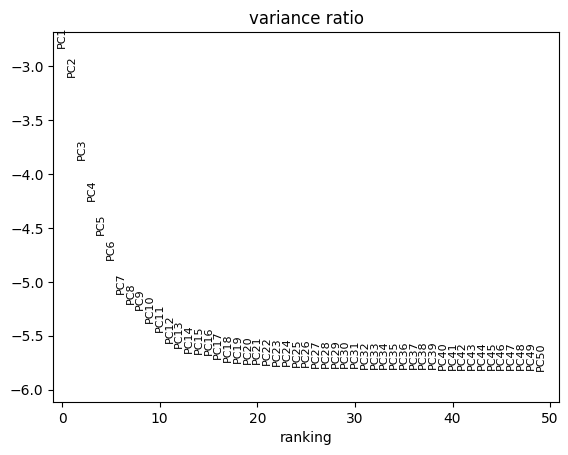

In [14]:
sc.pp.pca(adata2, n_comps=50, svd_solver="arpack", random_state=0)

# 看解释方差比，决定保留多少PC
sc.pl.pca_variance_ratio(adata2, log=True, n_pcs=50)

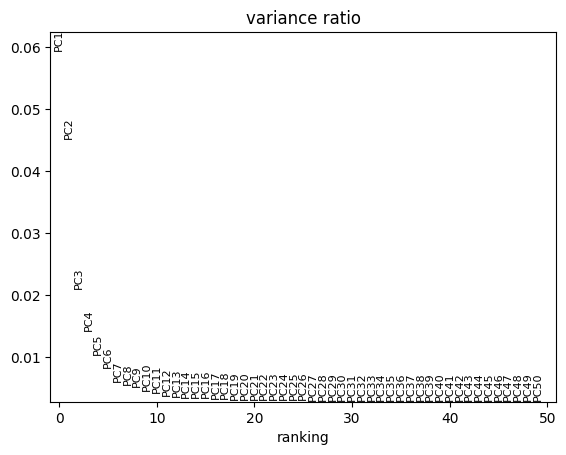

In [15]:
sc.pl.pca_variance_ratio(adata2, log=False, n_pcs=50)

In [16]:
n_pcs_use = 20

sc.pp.neighbors(
    adata2,
    n_neighbors=15,
    n_pcs=n_pcs_use,
    metric="euclidean",
    random_state=0
)

In [17]:
adata2.write(f"{output_path}/adatakNNPCA.h5ad")

In [ ]:
# 先扫一遍 resolution，看看大概会分成多少类
for res in [0.3, 0.5, 0.7, 0.9, 1.1, 1.3,1.5,1.8]:
    key = f"leiden_{res}"
    sc.tl.leiden(adata2, resolution=res, key_added=key, random_state=0)
    print(key, "n_clusters =", adata2.obs[key].nunique())

leiden_0.3 n_clusters = 6
leiden_0.5 n_clusters = 8
leiden_0.7 n_clusters = 10
leiden_0.9 n_clusters = 10
leiden_1.1 n_clusters = 11
leiden_1.3 n_clusters = 12
leiden_1.5 n_clusters = 14
leiden_1.8 n_clusters = 19


In [19]:
for res in [1.7]:
    key = f"leiden_{res}"
    sc.tl.leiden(adata2, resolution=res, key_added=key, random_state=0)
    print(key, "n_clusters =", adata2.obs[key].nunique())

leiden_1.7 n_clusters = 20


In [ ]:
res=1.8
sc.tl.leiden(adata2, resolution=res, key_added="cluster", random_state=0)
adata2.obs["cluster"] = adata2.obs["cluster"].astype("category")

In [ ]:
sc.tl.umap(adata2, random_state=0)

In [ ]:
adata2.write(f"/p2/zulab/jtian/data/SA/06_calculateConcentration/output_Leiden_ClusterLR/adataProcessedRes{res}.h5ad")

In [ ]:
sc.pl.umap(
    adata2,
    color=["cluster", "sample"],
    wspace=0.35,
    legend_loc="right margin",
    size=8
)
out_dir = '/p2/zulab/jtian/data/SA/06_calculateConcentration/output_Leiden_ClusterLR'
plt.savefig(os.path.join(out_dir, f"umap_cluster_sample_res{res}.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [ ]:
# 统一颜色
cats = adata2.obs["cluster"].cat.categories.tolist()
cmap = plt.get_cmap("tab20", len(cats))
palette = {c: mpl.colors.to_hex(cmap(i)) for i, c in enumerate(cats)}

samples = ["0", "15", "30", "45", "60"]
fig, axes = plt.subplots(1, len(samples), figsize=(24, 5))

umap = adata2.obsm["X_umap"]

for ax, s in zip(axes, samples):
    idx = (adata2.obs["sample"].values.astype(str) == s)
    colors = adata2.obs.loc[idx, "cluster"].map(palette).values
    ax.scatter(umap[idx, 0], umap[idx, 1], c=colors, s=2, linewidths=0)
    ax.set_title(f"sample {s}")
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")

handles = [
    Line2D([0], [0], marker='o', color='w', label=c,
           markerfacecolor=palette[c], markersize=6)
    for c in cats
]
fig.legend(handles=handles, labels=cats, loc="center right", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(rect=[0, 0, 0.94, 1])
plt.savefig(os.path.join(out_dir, f"umap_by_sample_res{res}.png"), dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
fig, axes = plt.subplots(1, len(samples), figsize=(24, 5))

for ax, s in zip(axes, samples):
    idx = (adata2.obs["sample"].values.astype(str) == s)
    colors = adata2.obs.loc[idx, "cluster"].map(palette).values
    ax.scatter(
        adata2.obs.loc[idx, "x"],
        adata2.obs.loc[idx, "y"],
        c=colors,
        s=2,
        linewidths=0
    )
    ax.invert_yaxis()
    ax.set_title(f"sample {s}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

fig.legend(handles=handles, labels=cats, loc="center right", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(rect=[0, 0, 0.94, 1])
plt.savefig(os.path.join(out_dir, f"spatial_by_sample_res{res}.png"), dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
adata2.obs

In [ ]:
cluster=adata2.obs['cluster']

In [ ]:
cluster=cluster.reset_index(drop=True)

In [ ]:
cluster

In [ ]:
coordsLabelIntensity


ctrl3

embedding+leiden+UMAP

In [2]:
embed_dict = torch.load("/p2/zulab/jtian/data/SA/05_CAST/output_cast9/demo_embed_dict.pt",map_location='cpu')


In [3]:
adata=ad.read_h5ad("/p2/zulab/jtian/data/SA/05_CAST/output_cast9/demo1_cast9.h5ad")

In [4]:
samples = np.unique(adata.obs['sample'])
coords_dict={sample_t: np.array(adata.obs[['x','y']])[adata.obs['sample'] == sample_t] for sample_t in samples}

In [5]:
sample_list = ['0', '15', '30', '45', '60']
out_dir = "/p2/zulab/jtian/data/SA/05_CAST/umap_cluster"
os.makedirs(out_dir, exist_ok=True)

X_list = []
obs_list = []

for s in sample_list:
    emb = embed_dict[s]
    emb = emb.detach().cpu().numpy()
    coords = np.asarray(coords_dict[s])

    obs_tmp = pd.DataFrame({
        'sample': s,
        'x': coords[:, 0],
        'y': coords[:, 1],
        'cell_id_in_sample': np.arange(emb.shape[0])
    })

    X_list.append(emb)
    obs_list.append(obs_tmp)

X_all = np.vstack(X_list)
obs_all = pd.concat(obs_list, axis=0).reset_index(drop=True)

embAdata = ad.AnnData(X=X_all, obs=obs_all)

# 在 CAST embedding 上建图
sc.pp.neighbors(embAdata, n_neighbors=15, use_rep='X')

# UMAP 可视化
sc.tl.umap(embAdata, min_dist=0.3, spread=1.0, random_state=0)

# 真正聚类
sc.tl.leiden(embAdata, resolution=0.5, key_added='cluster')

# 保存 obs 表
embAdata.obs.to_csv(os.path.join(out_dir, "embedding_cluster_results.csv"), index=False)

# 保存联合 UMAP 图
sc.pl.umap(embAdata, color=['sample', 'cluster'], wspace=0.4, show=False)
plt.savefig(os.path.join(out_dir, "umap_sample_cluster.png"), dpi=300, bbox_inches='tight')
plt.close()

# 保存每个样本的空间分布图
for s in sample_list:
    idx = embAdata.obs['sample'] == s

    plt.figure(figsize=(5, 5))
    plt.scatter(
        embAdata.obs.loc[idx, 'x'],
        embAdata.obs.loc[idx, 'y'],
        c=embAdata.obs.loc[idx, 'cluster'].astype(int),
        s=3
    )
    plt.gca().invert_yaxis()
    plt.title(f"{s} spatial clusters")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.savefig(os.path.join(out_dir, f"{s}_spatial_clusters.png"), dpi=300, bbox_inches='tight')
    plt.close()

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


原始数据PCA+leiden+UMAP

In [4]:
#1.构建Anndata
# 读入intensity文件
intensity0 = pd.read_csv("/p1/data/jtian/SA/05_CAST/input/LipidsIntensity/lipids0.csv", sep=";", header = 0, index_col = 0)
intensity15 = pd.read_csv("/p1/data/jtian/SA/05_CAST/input/LipidsIntensity/lipids15.csv", sep=";", header = 0, index_col = 0)
intensity30 = pd.read_csv("/p1/data/jtian/SA/05_CAST/input/LipidsIntensity/lipids30.csv", sep=";", header = 0, index_col = 0)
intensity45 = pd.read_csv("/p1/data/jtian/SA/05_CAST/input/LipidsIntensity/lipids45.csv", sep=";", header = 0, index_col = 0)
intensity60 = pd.read_csv("/p1/data/jtian/SA/05_CAST/input/LipidsIntensity/lipids60.csv", sep=";", header = 0, index_col = 0)
intensity0.index.name ='mz'
intensity15.index.name ='mz'
intensity30.index.name ='mz'
intensity45.index.name ='mz'
intensity60.index.name ='mz'
#打印形状 (Shape)
print("--- 数据形状 (Shape) ---")
print(intensity0.shape)
print(intensity15.shape)
print(intensity30.shape)
print(intensity45.shape)
print(intensity60.shape)

#打印前几行数据 (Head)
print("\n--- 数据预览 (Head) ---")
print("样本 0:")
print(intensity0.head())
print("\n样本 15:")
print(intensity15.head())
print("\n样本 30:")
print(intensity30.head())
print("\n样本 45:")
print(intensity45.head())
print("\n样本 60:")
print(intensity60.head())

SAMPLE_IDS = [0, 15, 30, 45, 60]
for sample_id in SAMPLE_IDS:
    file_name = f'lipids{sample_id}RegionSpots.csv'
    input_path='/p1/data/jtian/SA/05_CAST/input/LipidsSpotsIndex/'
    full_path = os.path.join(input_path, file_name)
    variable_name = f'SpotIndex{sample_id}'
    
    try:
        df_loaded = pd.read_csv(
            full_path, 
            sep=";", 
            header=0, 
            index_col=0 
        )
        
        # 使用 globals() 动态创建变量
        # 这一步将 df_loaded 赋值给名为 'SpotIndex0', 'SpotIndex15' 等的变量
        globals()[variable_name] = df_loaded
        df_loaded.index.name = 'SpotIndex'
        
        print(f"✅ 成功读入文件，并创建变量: {variable_name} (前5行: {df_loaded.head()})")
    except FileNotFoundError:
        print(f"❌ 错误: 文件未找到 - {full_path}")
    except pd.errors.ParserError as e:
        print(f"❌ 读取错误 ({file_name}): {e}")

print("\n--- 所有文件读入完成 ---")

SAMPLE_IDS = [0, 15, 30, 45, 60]

# --- 1. 初始化容器 ---
all_X_t = []  # 存储转置后的特征矩阵 (Spot x Metabolite)
all_obs = []  # 存储所有的观测值 (坐标和样本ID)
all_var_names = None # 存储代谢物 mz 值/索引

print("开始整合数据...")

for sample_id in SAMPLE_IDS:
    # 动态获取已加载的 Pandas DataFrame 变量
    intensity_df = globals()[f'intensity{sample_id}']
    coords_df = globals()[f'SpotIndex{sample_id}']

    print(f"\n整合样本 {sample_id}...")

    # --- 2. 处理特征矩阵 (创建 .X) ---
    # AnnData 要求：行是 Spot，列是 Metabolite。
    # 原始 intensity_df 形状是 (Metabolite, Spot)。需要转置 (T) 并提取值 (.values)。
    X_t = intensity_df.T.values
    all_X_t.append(X_t)

    # --- 3. 处理观测值 (创建 .obs) ---
    # 确保 Spot 顺序一致性：使用 intensity_df 的列名 (Spot Index) 来对 coords_df 进行索引排序。
    spot_indices_intensity = intensity_df.columns

    # 提取坐标信息并确保顺序匹配
    # CAST 要求 .obs 包含 'x', 'y', 'sample'
    try:
        # 提取数字部分并转换为整数（处理 "Spot 1" -> 1）
        spot_indices_numeric = []
        for spot_str in spot_indices_intensity:
            numeric_id = int(spot_str.replace("Spot ", "").strip())
            spot_indices_numeric.append(numeric_id)
            # 第二步：使用转换后的数字索引匹配 coords_df 的索引
        obs_t = coords_df.loc[spot_indices_numeric, ['x', 'y']].copy()
    except KeyError as e:
        print(f"❌ 错误：样本 {sample_id} 的坐标文件缺少 'x'/'y' 列，或 Spot 索引不存在。缺失项: {e}")
        continue
    except ValueError as e:
        print(f"❌ 错误：样本 {sample_id} 的 Spot 索引格式解析失败（不是 'Spot 数字' 格式）。详情: {e}")
        continue
    except Exception as e:
        print(f"❌ 错误：样本 {sample_id} 的 Spot 索引不匹配或存在其他问题。详细信息: {e}")
        continue
    # try:
    #     # 使用 loc 确保 coords_df 的 Spot 索引与 intensity_df 的列名（Spot Index）顺序一致
    #     obs_t = coords_df.loc[spot_indices_intensity, ['x', 'y']].copy()
    # except KeyError as e:
    #     print(f"❌ 错误：样本 {sample_id} 的坐标文件缺少 'x' 或 'y' 列。请检查文件。缺失列: {e}")
    #     # 如果出错，跳过该样本，但如果所有样本都出错，则最终 adata 会失败。
    #     continue
    # except Exception as e:
    #     print(f"❌ 错误：样本 {sample_id} 的 Spot 索引不匹配或存在其他问题。详细信息: {e}")
    #     continue
    
    # 添加样本 ID
    obs_t[['x', 'y']] = np.floor(obs_t[['x', 'y']].to_numpy()).astype(int)       #########################
    obs_t['sample'] = str(sample_id)
    all_obs.append(obs_t)

    # --- 4. 处理变量名 (创建 .var) ---
    # AnnData 要求：.var 的索引是特征 ID (mz 值)
    if all_var_names is None:
        # 使用 mz 值作为所有样本共享的变量名 (特征 ID)
        all_var_names = intensity_df.index.astype(str)
        # 验证所有样本的 mz 值是否一致
        for next_sample_id in SAMPLE_IDS:
             next_intensity_df = globals()[f'intensity{next_sample_id}']
             if not all_var_names.equals(next_intensity_df.index.astype(str)):
                 print("⚠️ 警告：不同样本的 $m/z$ 值（代谢物）列表不完全一致。这将使用第一个样本的 $m/z$ 列表。")
                 break

# --- 5. 整合所有样本的数据 ---

if not all_X_t:
    print("❌ 错误：没有成功处理任何样本，无法创建 AnnData 对象。")
else:
    # 合并所有样本的特征矩阵（Spot x Metabolite）
    X_combined = np.vstack(all_X_t)
    
    # 合并所有样本的观测值（坐标和样本 ID）
    obs_combined = pd.concat(all_obs, axis=0)
    
    # 创建变量 (特征) DataFrame，索引是 $m/z$ 值
    var_df = pd.DataFrame(index=all_var_names)
    
    # --- 6. 构建最终 AnnData 对象 ---
    print("\n构建 AnnData 对象...")
    adata = ad.AnnData(
        X=X_combined,
        obs=obs_combined,
        var=var_df,
        dtype=X_combined.dtype
    )
    out_dir = '/p2/zulab/jtian/data/SA/06_calculateConcentration/output_Leiden_ClusterLR'
    os.makedirs(out_dir, exist_ok=True)  
    OUTPUT_H5AD = f'{out_dir}/adata_raw.h5ad'
    adata.write_h5ad(OUTPUT_H5AD)

--- 数据形状 (Shape) ---
(336, 47395)
(336, 53409)
(336, 45217)
(336, 50676)
(336, 50664)

--- 数据预览 (Head) ---
样本 0:
            Spot 1    Spot 2    Spot 3    Spot 4    Spot 5    Spot 6  \
mz                                                                     
402.2409  0.000000  0.000000  0.410255  0.481486  0.000000  0.364722   
403.2578  0.000000  0.334832  0.587663  0.000000  0.333195  0.000000   
404.2571  0.000000  0.377759  0.000000  0.228072  0.558592  0.295251   
405.2771  0.408679  0.154538  0.210672  0.565957  0.000000  0.095522   
406.2774  0.000000  0.137367  0.166320  0.101366  0.000000  0.243148   

            Spot 7    Spot 8    Spot 9   Spot 10  ...  Spot 47386  Spot 47387  \
mz                                                ...                           
402.2409  0.391104  0.000000  0.675982  0.442334  ...    2.947146    1.562441   
403.2578  0.108640  0.000000  0.195937  0.000000  ...    3.831290    3.192815   
404.2571  0.304192  0.309417  0.000000  0.000000  ...    3

In [5]:
adata

AnnData object with n_obs × n_vars = 247361 × 336
    obs: 'x', 'y', 'sample'

In [7]:
adata2 = adata.copy()

# 保存原始矩阵
adata2.layers["raw"] = adata2.X.copy()

# 保证 sample 是字符串，后面画图方便
adata2.obs["sample"] = adata2.obs["sample"].astype(str)

# 保证坐标是数值型
adata2.obs["x"] = pd.to_numeric(adata2.obs["x"])
adata2.obs["y"] = pd.to_numeric(adata2.obs["y"])

In [8]:
X = adata2.X

# 每个spot的总信号
spot_sum = np.asarray(X.sum(axis=1)).ravel() if sparse.issparse(X) else X.sum(axis=1)

# 每个spot检测到的代谢物数（>0 视为检测到）
n_detected = np.asarray((X > 0).sum(axis=1)).ravel() if sparse.issparse(X) else (X > 0).sum(axis=1)

adata2.obs["tic"] = spot_sum
adata2.obs["n_met_detected"] = n_detected

# 先去掉完全空白或极低信息spot
spot_keep = (adata2.obs["tic"] > 0) & (adata2.obs["n_met_detected"] >= 10)
adata2 = adata2[spot_keep].copy()

# 过滤极少出现的代谢物
X = adata2.X
met_detected = np.asarray((X > 0).sum(axis=0)).ravel() if sparse.issparse(X) else (X > 0).sum(axis=0)
adata2.var["n_spots_detected"] = met_detected

min_spots = max(20, int(0.001 * adata2.n_obs))   # 至少在0.1%的spots中出现
adata2 = adata2[:, adata2.var["n_spots_detected"] >= min_spots].copy()

In [ ]:
adata2.X = (adata2.X * 10).round().astype(int)

sc.pp.normalize_total(adata2, target_sum=1e5)

sc.pp.log1p(adata2)

adata2.layers["log_norm"] = adata2.X.copy()

In [10]:
sc.pp.scale(adata2, zero_center=True, max_value=10)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


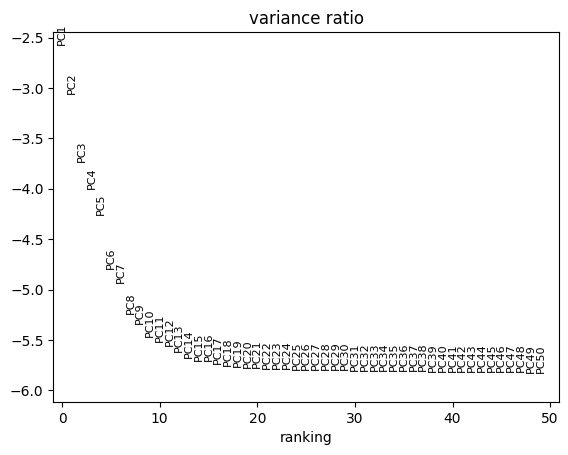

In [11]:
sc.pp.pca(adata2, n_comps=50, svd_solver="arpack", random_state=0)

# 看解释方差比，决定保留多少PC
sc.pl.pca_variance_ratio(adata2, log=True, n_pcs=50)

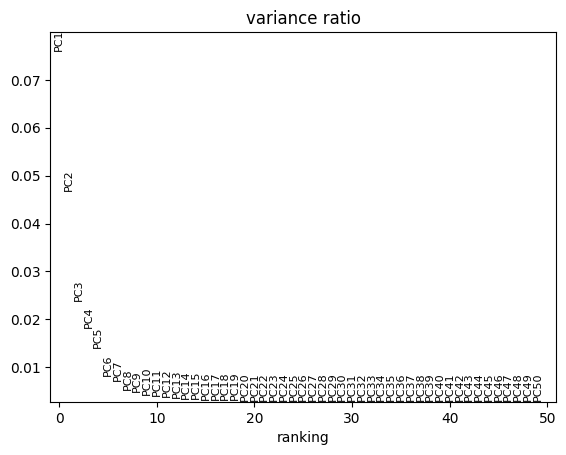

In [12]:
sc.pl.pca_variance_ratio(adata2, log=False, n_pcs=50)

In [13]:
n_pcs_use = 20

sc.pp.neighbors(
    adata2,
    n_neighbors=15,
    n_pcs=n_pcs_use,
    metric="euclidean",
    random_state=0
)

In [15]:
adata2.write("/p2/zulab/jtian/data/SA/06_calculateConcentration/output_Leiden_ClusterLR/adataC3kNNPCA.h5ad")

In [3]:
adata2 = ad.read_h5ad("/p2/zulab/jtian/data/SA/06_calculateConcentration/output_Leiden_ClusterLR/adataC3kNNPCA.h5ad")

In [3]:
# 先扫一遍 resolution，看看大概会分成多少类
for res in [0.3, 0.5, 0.7, 0.9, 1.1, 1.3]:
    key = f"leiden_{res}"
    sc.tl.leiden(adata2, resolution=res, key_added=key, random_state=0)
    print(key, "n_clusters =", adata2.obs[key].nunique())

leiden_0.3 n_clusters = 6
leiden_0.5 n_clusters = 8
leiden_0.7 n_clusters = 9
leiden_0.9 n_clusters = 11
leiden_1.1 n_clusters = 12
leiden_1.3 n_clusters = 14


In [4]:
for res in [1.5,1.8]:
    key = f"leiden_{res}"
    sc.tl.leiden(adata2, resolution=res, key_added=key, random_state=0)
    print(key, "n_clusters =", adata2.obs[key].nunique())

leiden_1.5 n_clusters = 16
leiden_1.8 n_clusters = 18


In [59]:
res=1.8
sc.tl.leiden(adata2, resolution=res, key_added="cluster", random_state=0)
adata2.obs["cluster"] = adata2.obs["cluster"].astype("category")

In [60]:
sc.tl.umap(adata2, random_state=0)

In [61]:
adata2.write(f"/p2/zulab/jtian/data/SA/06_calculateConcentration/output_Leiden_ClusterLR/adataC3ProcessedRes{res}.h5ad")

In [72]:
adata2

AnnData object with n_obs × n_vars = 247361 × 336
    obs: 'x', 'y', 'sample', 'tic', 'n_met_detected', 'leiden_0.3', 'cluster'
    var: 'n_spots_detected', 'mean', 'std'
    uns: 'leiden_0.3', 'log1p', 'neighbors', 'pca', 'cluster', 'umap', 'cluster_colors', 'sample_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'log_norm', 'raw'
    obsp: 'connectivities', 'distances'

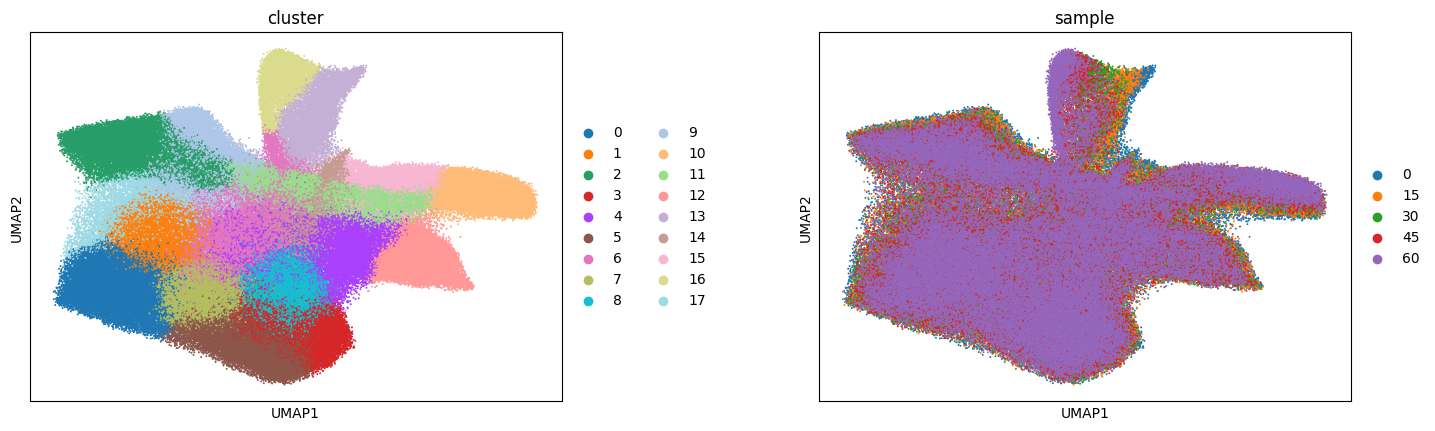

<Figure size 640x480 with 0 Axes>

In [62]:
sc.pl.umap(
    adata2,
    color=["cluster", "sample"],
    wspace=0.35,
    legend_loc="right margin",
    size=8
)
out_dir = '/p2/zulab/jtian/data/SA/06_calculateConcentration/output_Leiden_ClusterLR'
plt.savefig(os.path.join(out_dir, f"umap_cluster_sample_res{res}.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

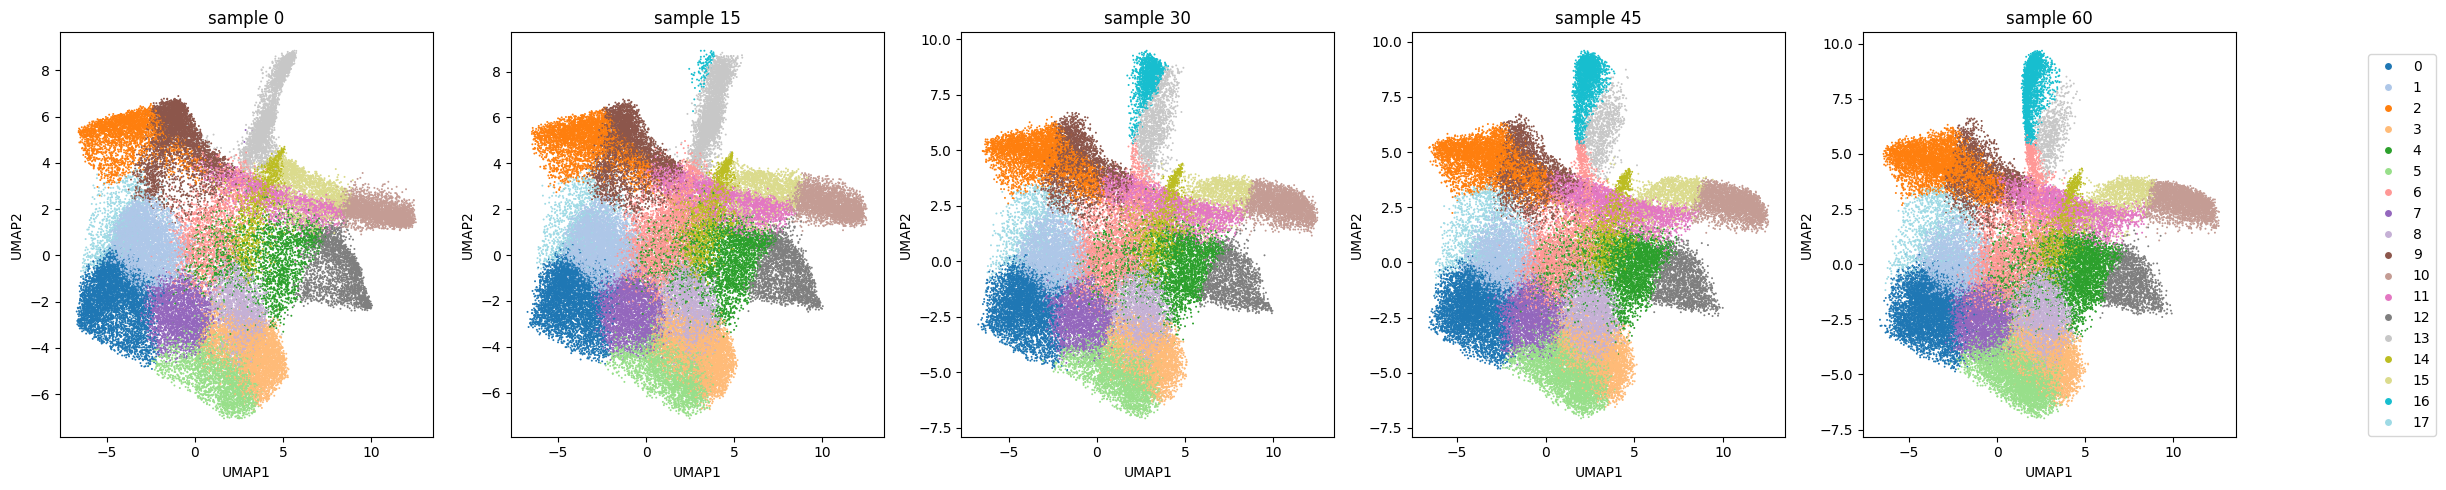

In [63]:
# 统一颜色
cats = adata2.obs["cluster"].cat.categories.tolist()
cmap = plt.get_cmap("tab20", len(cats))
palette = {c: mpl.colors.to_hex(cmap(i)) for i, c in enumerate(cats)}

samples = ["0", "15", "30", "45", "60"]
fig, axes = plt.subplots(1, len(samples), figsize=(24, 5))

umap = adata2.obsm["X_umap"]

for ax, s in zip(axes, samples):
    idx = (adata2.obs["sample"].values.astype(str) == s)
    colors = adata2.obs.loc[idx, "cluster"].map(palette).values
    ax.scatter(umap[idx, 0], umap[idx, 1], c=colors, s=2, linewidths=0)
    ax.set_title(f"sample {s}")
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")

handles = [
    Line2D([0], [0], marker='o', color='w', label=c,
           markerfacecolor=palette[c], markersize=6)
    for c in cats
]
fig.legend(handles=handles, labels=cats, loc="center right", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(rect=[0, 0, 0.94, 1])
plt.savefig(os.path.join(out_dir, f"umap_by_sample_res{res}.png"), dpi=300, bbox_inches="tight")
plt.show()

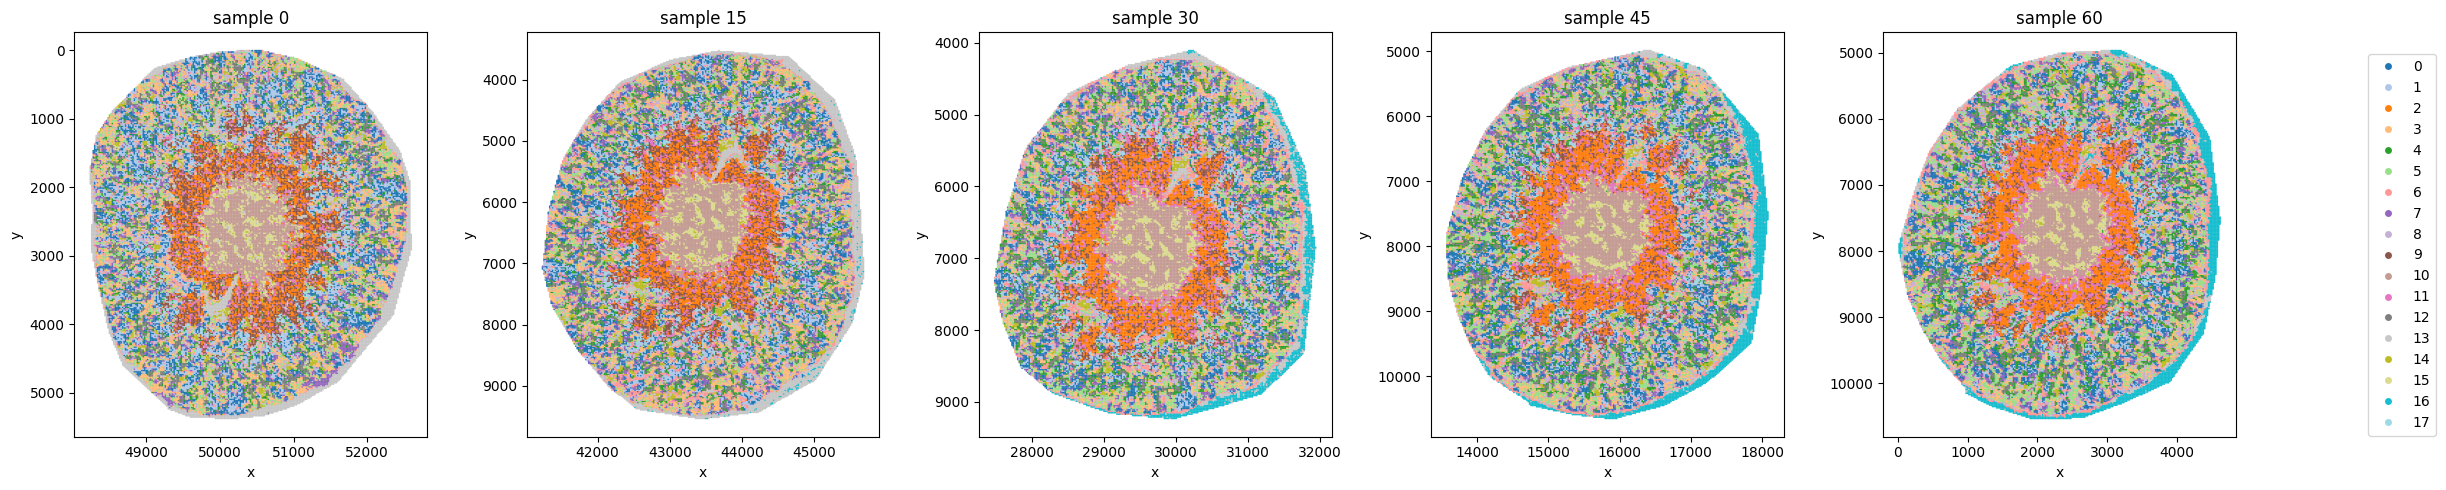

In [64]:
fig, axes = plt.subplots(1, len(samples), figsize=(24, 5))

for ax, s in zip(axes, samples):
    idx = (adata2.obs["sample"].values.astype(str) == s)
    colors = adata2.obs.loc[idx, "cluster"].map(palette).values
    ax.scatter(
        adata2.obs.loc[idx, "x"],
        adata2.obs.loc[idx, "y"],
        c=colors,
        s=2,
        linewidths=0
    )
    ax.invert_yaxis()
    ax.set_title(f"sample {s}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

fig.legend(handles=handles, labels=cats, loc="center right", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(rect=[0, 0, 0.94, 1])
plt.savefig(os.path.join(out_dir, f"spatial_by_sample_res{res}.png"), dpi=300, bbox_inches="tight")
plt.show()

In [14]:
adata2.obs

,x,y,sample,tic,n_met_detected,leiden_0.3,cluster
SpotIndex,,,,,,,
1,49939,5370,0,120.941595,236,4,7
2,49959,5370,0,114.813038,229,4,7
3,49979,5370,0,90.799454,205,4,7
4,49999,5370,0,99.608509,217,4,7
5,50019,5370,0,94.509892,216,4,7
...,...,...,...,...,...,...,...
247357,3119,4970,60,805.042285,249,4,7
247358,3139,4970,60,815.212527,261,4,7
247359,3159,4970,60,1132.142624,257,4,7


In [65]:
cluster=adata2.obs['cluster']

In [66]:
cluster=cluster.reset_index(drop=True)

In [67]:
cluster

0         13
1         13
2         13
3         13
4         13
          ..
247356    16
247357    16
247358    16
247359    16
247360    16
Name: cluster, Length: 247361, dtype: category
Categories (18, object): ['0', '1', '2', '3', ..., '14', '15', '16', '17']

In [73]:
coordsLabelIntensity=pd.read_csv("/p2/zulab/jtian/data/SA/06_calculateConcentration/output_calculateByClusterLR/coordsLabelIntensity.csv")


In [74]:
coordsLabelIntensity

,Unnamed: 0,sample,cell_label,57.0346,58.0296,59.0139,67.0191,71.0137,71.0503,72.0091,...,856.5052,859.5297,860.536,863.5618,864.5684,882.5853,921.5991,923.615,985.6046,986.6105
0,1,0,5,0.208880,0.254289,0.499496,0.399597,1.607469,0.127144,0.962665,...,0.363270,0.481332,0.163471,0.000000,0.435924,0.308779,0.000000,0.000000,0.163471,0.000000
1,2,0,5,0.000000,0.223221,0.480784,0.257563,2.481191,0.000000,1.210547,...,0.712591,0.154538,0.283319,0.394930,0.463614,0.257563,0.154538,0.000000,0.120196,0.412101
2,3,0,5,0.000000,0.000000,1.175326,0.720719,0.698543,0.000000,0.155232,...,0.177408,0.155232,0.221760,0.410255,0.000000,0.000000,0.000000,0.232848,0.654191,0.343727
3,4,0,5,0.152048,0.000000,0.557510,0.000000,0.726453,0.000000,0.278755,...,0.084471,0.000000,0.194284,0.304097,0.464592,0.312544,0.278755,0.000000,0.000000,0.000000
4,5,0,5,0.000000,0.000000,0.725190,0.382195,2.587164,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.088199,0.244997,0.244997,0.195997,0.000000,0.391995,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247356,247357,60,5,2.105920,0.399399,10.329899,2.178538,39.013979,1.216350,4.302612,...,4.393384,5.627889,0.000000,3.558278,1.670212,2.723172,1.379741,1.760985,3.739823,2.360082
247357,247358,60,5,2.115093,0.459090,16.691198,1.278893,49.745672,2.672559,4.115413,...,3.148045,4.640087,0.000000,3.672719,2.623371,1.869152,1.721587,0.950972,4.230186,2.229865
247358,247359,60,5,1.906487,2.017329,14.121301,2.793224,41.831861,0.532043,6.916556,...,3.591289,5.918976,5.054406,4.655374,2.083834,1.950823,2.394192,1.773476,5.409101,2.726719
247359,247360,60,5,1.522979,3.635498,7.148176,0.000000,30.975429,1.007131,2.554675,...,8.622027,11.299522,7.393818,7.614895,4.102218,6.091916,2.309033,1.940570,5.035657,2.972266


In [75]:
coordsLabelIntensity.drop(coordsLabelIntensity.columns[[0,2]],axis=1,inplace=True)

In [76]:
coordsLabelIntensity

,sample,57.0346,58.0296,59.0139,67.0191,71.0137,71.0503,72.0091,72.017,73.0294,...,856.5052,859.5297,860.536,863.5618,864.5684,882.5853,921.5991,923.615,985.6046,986.6105
0,0,0.208880,0.254289,0.499496,0.399597,1.607469,0.127144,0.962665,0.354188,0.563068,...,0.363270,0.481332,0.163471,0.000000,0.435924,0.308779,0.000000,0.000000,0.163471,0.000000
1,0,0.000000,0.223221,0.480784,0.257563,2.481191,0.000000,1.210547,0.000000,0.875714,...,0.712591,0.154538,0.283319,0.394930,0.463614,0.257563,0.154538,0.000000,0.120196,0.412101
2,0,0.000000,0.000000,1.175326,0.720719,0.698543,0.000000,0.155232,0.000000,0.000000,...,0.177408,0.155232,0.221760,0.410255,0.000000,0.000000,0.000000,0.232848,0.654191,0.343727
3,0,0.152048,0.000000,0.557510,0.000000,0.726453,0.000000,0.278755,0.143601,0.574405,...,0.084471,0.000000,0.194284,0.304097,0.464592,0.312544,0.278755,0.000000,0.000000,0.000000
4,0,0.000000,0.000000,0.725190,0.382195,2.587164,0.000000,0.000000,0.000000,1.460180,...,0.000000,0.000000,0.000000,0.088199,0.244997,0.244997,0.195997,0.000000,0.391995,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247356,60,2.105920,0.399399,10.329899,2.178538,39.013979,1.216350,4.302612,0.000000,8.641533,...,4.393384,5.627889,0.000000,3.558278,1.670212,2.723172,1.379741,1.760985,3.739823,2.360082
247357,60,2.115093,0.459090,16.691198,1.278893,49.745672,2.672559,4.115413,0.000000,20.085184,...,3.148045,4.640087,0.000000,3.672719,2.623371,1.869152,1.721587,0.950972,4.230186,2.229865
247358,60,1.906487,2.017329,14.121301,2.793224,41.831861,0.532043,6.916556,0.000000,24.584808,...,3.591289,5.918976,5.054406,4.655374,2.083834,1.950823,2.394192,1.773476,5.409101,2.726719
247359,60,1.522979,3.635498,7.148176,0.000000,30.975429,1.007131,2.554675,0.000000,14.713943,...,8.622027,11.299522,7.393818,7.614895,4.102218,6.091916,2.309033,1.940570,5.035657,2.972266


In [77]:
coordsLabelIntensity = pd.concat([cluster,coordsLabelIntensity],axis=1)

In [78]:
coordsLabelIntensity

,cluster,sample,57.0346,58.0296,59.0139,67.0191,71.0137,71.0503,72.0091,72.017,...,856.5052,859.5297,860.536,863.5618,864.5684,882.5853,921.5991,923.615,985.6046,986.6105
0,13,0,0.208880,0.254289,0.499496,0.399597,1.607469,0.127144,0.962665,0.354188,...,0.363270,0.481332,0.163471,0.000000,0.435924,0.308779,0.000000,0.000000,0.163471,0.000000
1,13,0,0.000000,0.223221,0.480784,0.257563,2.481191,0.000000,1.210547,0.000000,...,0.712591,0.154538,0.283319,0.394930,0.463614,0.257563,0.154538,0.000000,0.120196,0.412101
2,13,0,0.000000,0.000000,1.175326,0.720719,0.698543,0.000000,0.155232,0.000000,...,0.177408,0.155232,0.221760,0.410255,0.000000,0.000000,0.000000,0.232848,0.654191,0.343727
3,13,0,0.152048,0.000000,0.557510,0.000000,0.726453,0.000000,0.278755,0.143601,...,0.084471,0.000000,0.194284,0.304097,0.464592,0.312544,0.278755,0.000000,0.000000,0.000000
4,13,0,0.000000,0.000000,0.725190,0.382195,2.587164,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.088199,0.244997,0.244997,0.195997,0.000000,0.391995,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247356,16,60,2.105920,0.399399,10.329899,2.178538,39.013979,1.216350,4.302612,0.000000,...,4.393384,5.627889,0.000000,3.558278,1.670212,2.723172,1.379741,1.760985,3.739823,2.360082
247357,16,60,2.115093,0.459090,16.691198,1.278893,49.745672,2.672559,4.115413,0.000000,...,3.148045,4.640087,0.000000,3.672719,2.623371,1.869152,1.721587,0.950972,4.230186,2.229865
247358,16,60,1.906487,2.017329,14.121301,2.793224,41.831861,0.532043,6.916556,0.000000,...,3.591289,5.918976,5.054406,4.655374,2.083834,1.950823,2.394192,1.773476,5.409101,2.726719
247359,16,60,1.522979,3.635498,7.148176,0.000000,30.975429,1.007131,2.554675,0.000000,...,8.622027,11.299522,7.393818,7.614895,4.102218,6.091916,2.309033,1.940570,5.035657,2.972266


In [79]:
intensity_cols = coordsLabelIntensity.columns[2:]

meanIntensity = (
    coordsLabelIntensity
    .groupby(['sample', 'cluster'], as_index=False)[intensity_cols]
    .mean()
)


In [80]:
meanIntensity

,sample,cluster,57.0346,58.0296,59.0139,67.0191,71.0137,71.0503,72.0091,72.017,...,856.5052,859.5297,860.536,863.5618,864.5684,882.5853,921.5991,923.615,985.6046,986.6105
0,0,0,0.675086,1.029037,4.398080,1.152619,19.834673,0.498852,1.479243,0.632799,...,3.498551,5.973683,4.037912,3.611438,2.468883,1.723626,1.580612,2.169294,1.140414,1.071440
1,0,1,0.681437,1.067502,4.423866,1.185294,19.330174,0.502772,1.609104,0.638006,...,3.364105,5.679549,3.850924,3.421125,2.298027,1.678913,1.517467,2.089637,1.139082,1.080905
2,0,2,0.703950,0.995091,4.554113,1.212839,21.100454,0.528589,1.690417,0.667200,...,3.181431,5.226242,3.962527,4.708006,2.807155,1.609834,1.371761,1.648987,1.026185,0.991914
3,0,3,0.698286,1.238249,4.601819,1.177485,20.407479,0.484366,1.692980,0.645237,...,3.561833,6.190578,3.980210,4.120580,2.699261,1.808202,1.546303,2.394006,1.224345,1.149712
4,0,4,0.729423,1.278108,4.575387,1.188939,20.785319,0.468753,1.767430,0.704286,...,3.214714,5.573843,3.559825,3.240923,2.313435,1.654270,1.411772,1.927752,1.190531,1.127551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,60,13,0.526658,0.605416,3.798050,0.931191,14.602652,0.590727,1.562584,0.485038,...,1.711925,2.481210,1.779475,1.970494,1.355216,1.030509,0.910657,0.876265,1.398192,1.164578
86,60,14,0.943785,1.676881,6.430389,1.579015,26.048504,0.835465,2.323286,0.840886,...,4.625451,7.682622,5.263978,5.711345,3.760265,2.200721,1.971083,2.167149,1.900075,1.666538
87,60,15,0.864317,1.335670,6.028311,1.532656,25.973940,0.806021,2.024537,0.862534,...,4.508236,8.138734,5.491071,7.024212,4.716958,2.194599,1.900173,2.201296,2.101273,1.811147
88,60,16,0.933966,1.573911,7.099817,1.426787,26.399543,1.113895,3.181267,0.827143,...,4.614247,7.729734,4.842895,5.616977,3.139490,2.120673,2.139726,1.996867,3.904954,2.987595


In [81]:
meanIntensity.to_csv(f"/p2/zulab/jtian/data/SA/06_calculateConcentration/output_Leiden_ClusterLR/meanIntensityBySampleByCluster_res{res}.csv")

In [82]:
def linreg_stats(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]; y = y[ok]
    n = len(x)
    if n < 2:
        return np.nan, np.nan, np.nan, np.nan

    xm = x.mean()
    ym = y.mean()
    dx = x - xm
    dy = y - ym

    varx = np.sum(dx * dx)
    if varx == 0:
        return np.nan, np.nan, np.nan, np.nan

    slope = np.sum(dx * dy) / varx
    intercept = ym - slope * xm

    yhat = slope * x + intercept
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - ym) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    # y=0 时 x 截距：x0 = -b/a；取绝对值
    x0_abs = np.abs(-intercept / slope) if slope != 0 else np.nan
    return slope, intercept, r2, x0_abs

In [83]:
sample_order = [0, 15, 30, 45, 60]   
mat = (
    meanIntensity
    .assign(sample=lambda d: d['sample'].astype(int),
            cluster=lambda d: d['cluster'].astype(int))
    .set_index(['cluster', 'sample'])[list(intensity_cols)]
    .sort_index()
)



In [84]:
results = []
x = np.array(sample_order, dtype=int)
for label in mat.index.get_level_values('cluster').unique():
    sub = mat.loc[label].reindex(sample_order)  # 行是 sample，列是代谢物

    for mz in sub.columns:
        y = sub[mz].values
        slope, intercept, r2, x0_abs = linreg_stats(x, y)
        results.append({
            'cluster': label,
            'metabolite': mz,
            'slope': slope,
            'intercept': intercept,
            'r2': r2,
            'x_intercept_abs': x0_abs,
        })

fit_df = pd.DataFrame(results)
fit_df.head()


,cluster,metabolite,slope,intercept,r2,x_intercept_abs
0,0,57.0346,0.003359,0.703766,0.917789,209.490265
1,0,58.0296,0.004505,1.062529,0.927363,235.848677
2,0,59.0139,0.027440,4.595325,0.940568,167.468814
3,0,67.0191,0.006334,1.168655,0.974778,184.498353
4,0,71.0137,0.095683,19.851396,0.997877,207.471537


In [85]:
fit_df

,cluster,metabolite,slope,intercept,r2,x_intercept_abs
0,0,57.0346,0.003359,0.703766,0.917789,209.490265
1,0,58.0296,0.004505,1.062529,0.927363,235.848677
2,0,59.0139,0.027440,4.595325,0.940568,167.468814
3,0,67.0191,0.006334,1.168655,0.974778,184.498353
4,0,71.0137,0.095683,19.851396,0.997877,207.471537
...,...,...,...,...,...,...
12523,17,882.5853,0.007892,1.803931,0.808943,228.577693
12524,17,921.5991,0.008424,1.612992,0.819181,191.466493
12525,17,923.615,0.005166,2.056142,0.730274,398.047518
12526,17,985.6046,0.010139,1.179738,0.904549,116.353640


In [86]:
fit_df = fit_df.sort_values(
    ['metabolite', 'cluster'],
    key=lambda s: pd.to_numeric(s)
)

In [87]:
fit_df = fit_df.set_index([ 'metabolite','cluster'])

In [88]:
fit_df.to_csv(f"/p2/zulab/jtian/data/SA/06_calculateConcentration/output_Leiden_ClusterLR/LRresults{res}.csv")


In [89]:
thr = 0.7

good_metabolites = (
    fit_df
    .groupby('metabolite')['r2']
    .apply(lambda s: (s > thr).all())
)

num_good = int(good_metabolites.sum())

In [90]:
num_good

189

In [91]:
r2MeanByMeta = fit_df.groupby('metabolite')['r2'].mean()

In [92]:
r2MeanByMeta

metabolite
100.0037    0.923883
101.0239    0.958221
101.0603    0.953233
101.0719    0.869035
102.0275    0.944004
              ...   
985.6046    0.880601
986.6105    0.861037
99.0077     0.776382
99.0448     0.897119
99.0562     0.867001
Name: r2, Length: 696, dtype: float64

In [93]:
thresholds = [0.9, 0.85, 0.8, 0.75, 0.7]

for thr in thresholds:
    r2_thr = r2MeanByMeta[r2MeanByMeta >= thr]
    print(f"r2_mean above {thr}: {r2_thr.shape[0]}")

r2_mean above 0.9: 334
r2_mean above 0.85: 529
r2_mean above 0.8: 601
r2_mean above 0.75: 633
r2_mean above 0.7: 654
